# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 2.
H = 1.

NGSOLVE = True

lc = 0.3

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [2]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

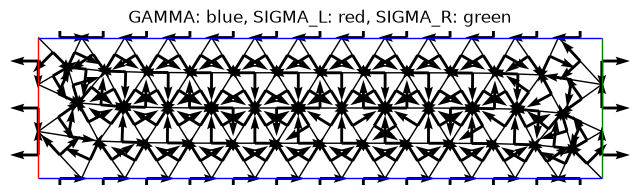

In [3]:
waveguide.plot()

In [4]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [5]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [6]:
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [7]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [8]:
from cases.waveguide.kernels import NtD_nonlocal, NtDLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [ ]:
from trefftz.dg.assemblers import SerialNumerics
n = 0
numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(R=R, d_2=0.5, n=n, H=H)},
                          nonlocal_boundary_kernels={NtDBC: NtD_nonlocal(R=R, d_2=0.5, M=10, H=H)})

We should also choose a local basis

In [34]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=3)

and an assembler:

In [35]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [36]:
from trefftz.problem import Problem  # (I don't think "problem" uses "numerics" any more.)
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=False)  #, numerics=numerics)

In [37]:
A = P.assemble_LHS()

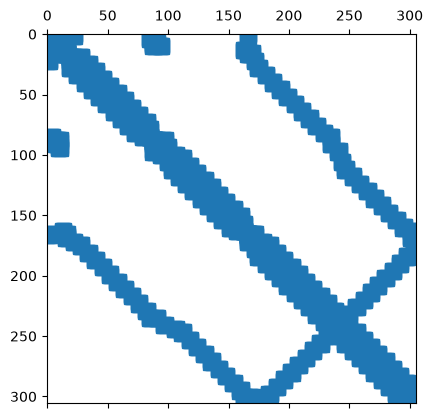

In [38]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [39]:
b = P.assemble_RHS()

In [40]:
P.solve()

In [41]:
P.u_h.coefficients.reshape((-1,3))

array([[ 1.01648025e+00-5.65922763e-02j,  6.77810279e-02+1.38678887e-01j,
        -6.96488605e-02-6.61892757e-03j],
       [ 1.22616584e+00-6.62566518e-01j,  1.08531789e+00+3.27315624e-01j,
         1.19565498e+00-4.33646300e-01j],
       [ 3.66596649e-01+3.54768280e-01j,  5.17061678e-02-9.67576462e-02j,
         5.20042373e-01+1.30611639e-01j],
       [ 4.63597750e-01+1.96529725e-01j,  8.96148080e-01-3.44810504e-01j,
        -1.31736373e-01-8.62402105e-02j],
       [ 7.86334248e-01-2.15150458e-02j,  1.71450995e-03+4.61956254e-02j,
        -2.45982551e-01+2.46740981e-03j],
       [ 1.00295201e+00+3.44970447e-02j, -1.37821645e-01+4.36817932e-02j,
         5.43847294e-04+1.30322574e-01j],
       [ 9.92002914e-01+3.89376590e-02j, -1.32334196e-02-1.98548618e-02j,
        -9.24550372e-02+4.92017146e-02j],
       [ 1.06796231e+00+1.05720876e-01j, -1.20783988e-01+3.31190410e-02j,
        -1.66485810e-01-4.97160418e-03j],
       [ 9.91934592e-01-1.37673501e-02j, -1.72004516e-02+3.31989452e-03j

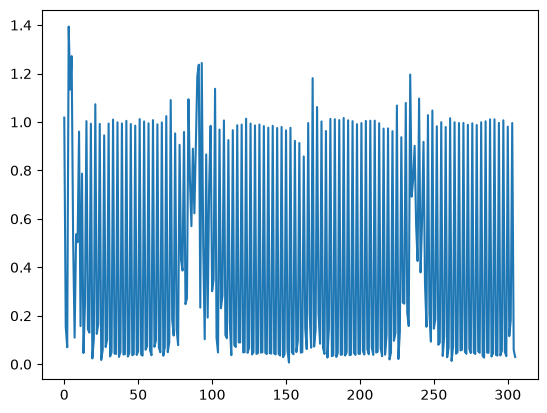

In [42]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [43]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

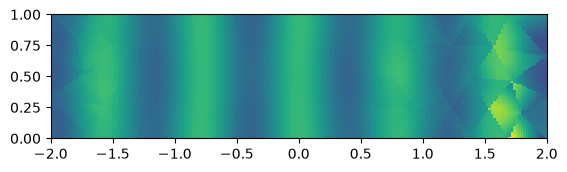

In [44]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real, vmin=-3, vmax=3)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])